<a href="https://colab.research.google.com/github/fatiyaqurrotuaini47-beep/UTS_FATIYAQURROTU-AINI/blob/main/UTS_NLP_FATIYAQA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Metode Embedding (Word2Vec)

In [128]:
!pip install nltk

In [129]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [130]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [131]:
pip install Sastrawi

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

!pip install gensim
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
file_path = '/content/drive/MyDrive/UTS_NLP/Fake.csv'
df = pd.read_csv(file_path)
df.head()

In [ ]:
print("Nama kolom pada dataset:")
print(df.columns.tolist())

MEMILIH KOLOM TEKS

In [ ]:
possible_text_cols = ['text']  # fokus ke text utama

text_col = None
for col in possible_text_cols:
    if col in df.columns:
        text_col = col
        break

print("Kolom teks yang digunakan:", text_col)

CLEANING TEXT

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

TOKENIZATION

In [ ]:
df['tokens'] = df['clean_text'].apply(word_tokenize)
df[['clean_text', 'tokens']].head()

STOPWORD REMOVAL (ENGLISH)

In [ ]:
stop_words = set(stopwords.words('english'))

df['tokens_no_stopwords'] = df['tokens'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words and len(word) > 2]
)

df[['tokens', 'tokens_no_stopwords']].head()

NORMALIZATION (DIKOSONGKAN BIAR STRUKTUR SAMA)

In [ ]:
# Tidak digunakan untuk dataset ini (bahasa formal)

def normalize_tokens(tokens):
    return tokens

df['tokens_normalized'] = df['tokens_no_stopwords'].apply(normalize_tokens)
df[['tokens_no_stopwords', 'tokens_normalized']].head(15)

MENGHAPUS BARIS KOSONG

In [ ]:
df = df[df['tokens_normalized'].apply(len) > 0].reset_index(drop=True)
print("Jumlah data setelah preprocessing:", len(df))
df.head()

MEMBUAT MODEL WORD2VEC

In [ ]:
# WAJIB ADA (perbaikan dari kode kamu)
sentences = df['tokens_normalized'].tolist()

model_w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1
)

print("Model Word2Vec berhasil dibuat")

MELIHAT VOCABULARY

In [ ]:
vocab = list(model_w2v.wv.index_to_key)
print("Jumlah vocabulary:", len(vocab))
print("20 kata pertama:", vocab[:20])

MENCARI KATA MIRIP

In [ ]:
kata_uji = ['trump', 'government', 'media', 'president', 'news']

for kata in kata_uji:
    if kata in model_w2v.wv:
        print(f"\nKata yang mirip dengan '{kata}':")
        print(model_w2v.wv.most_similar(kata, topn=5))
    else:
        print(f"\nKata '{kata}' tidak ditemukan dalam vocabulary.")

MELIHAT VEKTOR KATA

In [ ]:
if 'trump' in model_w2v.wv:
    print(model_w2v.wv['trump'][:10])
else:
    print("Kata tidak ditemukan dalam model.")

VEKTOR DOKUMEN

In [121]:
def document_vector(tokens, model):
    valid_words = [word for word in tokens if word in model.wv]
    if len(valid_words) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[valid_words], axis=0)

df['doc_vector'] = df['tokens_normalized'].apply(lambda x: document_vector(x, model_w2v))
df[['tokens_normalized', 'doc_vector']].head()

,tokens_normalized,doc_vector
0,"[donald, trump, wish, americans, happy, new, y...","[0.00016274807, 0.24490365, 0.036363896, 0.094..."
1,"[house, intelligence, committee, chairman, dev...","[0.08493546, 0.18638484, 0.06648523, 0.0766938..."
2,"[friday, revealed, former, milwaukee, sheriff,...","[0.06905035, 0.2264731, -0.06372108, 0.0376364..."
3,"[christmas, day, donald, trump, announced, wou...","[0.043832436, 0.17127614, 0.04627854, 0.041701..."
4,"[pope, francis, used, annual, christmas, day, ...","[0.0040834406, 0.2891425, 0.11622722, 0.116198..."


VISUALISASI FREKUENSI

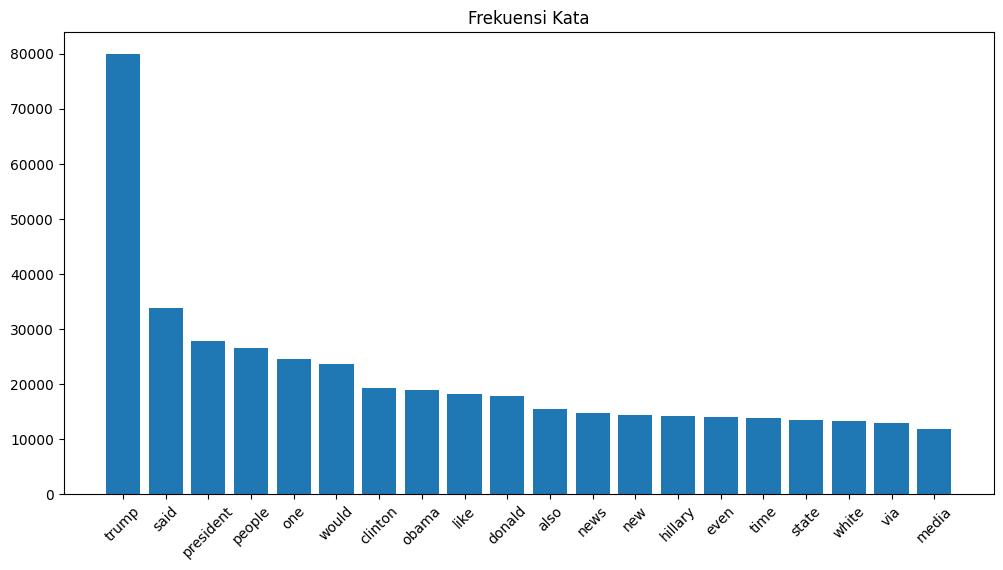

In [122]:
import matplotlib.pyplot as plt

words_to_plot = vocab[:20]

counts = []
for word in words_to_plot:
    total = sum(tokens.count(word) for tokens in df['tokens_normalized'])
    counts.append(total)

plt.figure(figsize=(12, 6))
plt.bar(words_to_plot, counts)
plt.xticks(rotation=45)
plt.title("Frekuensi Kata")
plt.show()

VISUALISASI SIMILARITY

Kata yang mirip dengan 'trump':
donald : 0.8562
flirted : 0.7135
elect : 0.6973
meteoric : 0.6827
accompli : 0.6690
cordial : 0.6635
scrutinize : 0.6589
pathetically : 0.6559
drumming : 0.6549
henchmen : 0.6546


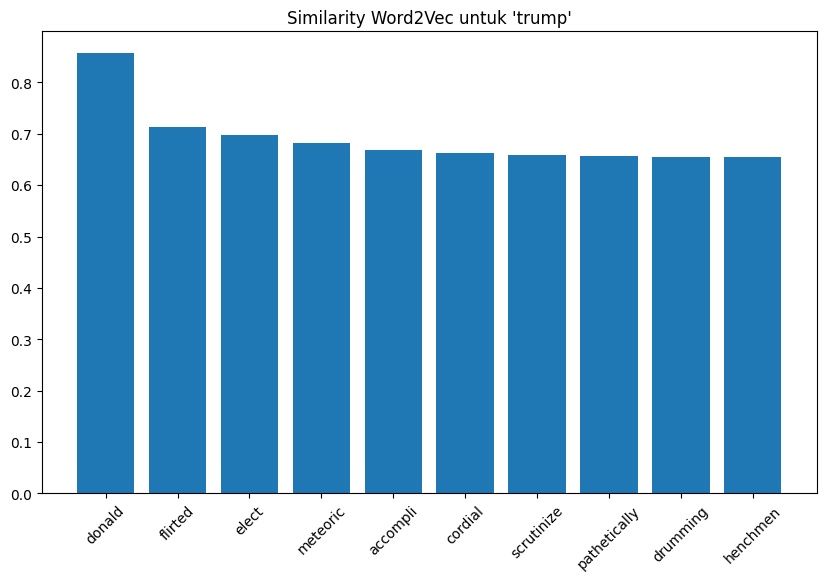

In [123]:
target_word = 'trump'

if target_word in model_w2v.wv:
    similar_words = model_w2v.wv.most_similar(target_word, topn=10)

    words = [word for word, score in similar_words]
    scores = [score for word, score in similar_words]

    print(f"Kata yang mirip dengan '{target_word}':")
    for word, score in similar_words:
        print(f"{word} : {score:.4f}")

    plt.figure(figsize=(10, 6))
    plt.bar(words, scores)
    plt.xticks(rotation=45)
    plt.title(f"Similarity Word2Vec untuk '{target_word}'")
    plt.show()

else:
    print(f"Kata '{target_word}' tidak ditemukan dalam vocabulary.")

(AUTO PILIH KATA)

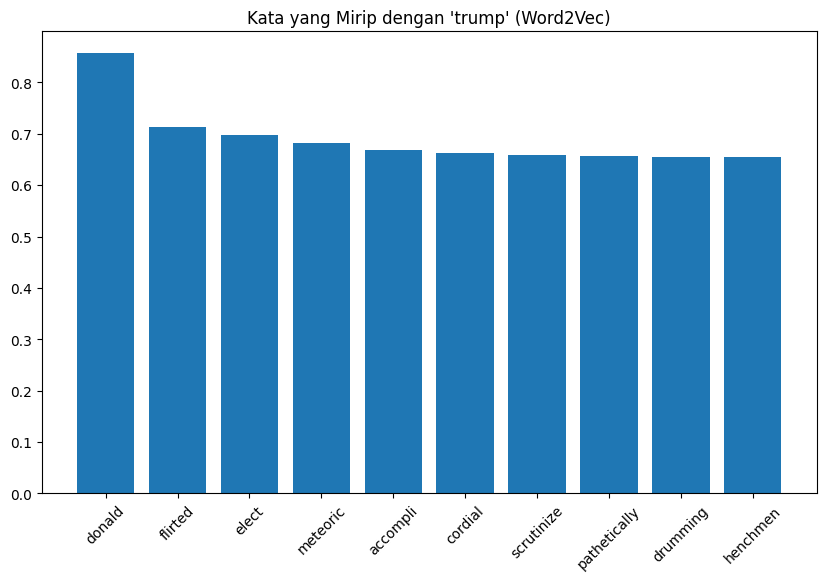

In [124]:
candidate_words = ['trump', 'government', 'media', 'president', 'news']

target_word = None
for word in candidate_words:
    if word in model_w2v.wv:
        target_word = word
        break

if target_word is not None:
    similar_words = model_w2v.wv.most_similar(target_word, topn=10)

    words = [word for word, score in similar_words]
    scores = [score for word, score in similar_words]

    plt.figure(figsize=(10, 6))
    plt.bar(words, scores)
    plt.xticks(rotation=45)
    plt.title(f"Kata yang Mirip dengan '{target_word}' (Word2Vec)")
    plt.show()

else:
    print("Tidak ada kata yang cocok di dalam vocabulary model.")

MENYIMPAN HASIL

In [125]:
output_path = '/content/hasil_preprocessing_fake_word2vec.csv'

df_save = df.copy()
df_save['doc_vector'] = df_save['doc_vector'].apply(lambda x: x.tolist())

df_save.to_csv(output_path, index=False)
print("Hasil disimpan di:", output_path)

Hasil disimpan di: /content/hasil_preprocessing_fake_word2vec.csv


MENYIMPAN MODEL

In [126]:
model_path = '/content/model_word2vec_fake.model'
model_w2v.save(model_path)

print("Model disimpan di:", model_path)

Model disimpan di: /content/model_word2vec_fake.model


KESIMPULAN

In [ ]:
print("Kesimpulan:")
print("1. Dataset Fake.csv berhasil diproses.")
print("2. Menggunakan gabungan title dan text.")
print("3. Preprocessing: cleaning, tokenization, stopword removal.")
print("4. Word2Vec digunakan sebagai representasi fitur.")
print("5. Model dan hasil berhasil disimpan.")

Kesimpulan:
1. Dataset Fake.csv berhasil diproses.
2. Menggunakan gabungan title dan text.
3. Preprocessing: cleaning, tokenization, stopword removal.
4. Word2Vec digunakan sebagai representasi fitur.
5. Model dan hasil berhasil disimpan.
